In [1]:
#Import Libraries

import pandas as pd 
import matplotlib.pyplot as plt 

plt.style.use("ggplot")


In [3]:
#Load Dataset

df = pd.read_csv("../data/salesdaily.csv")


In [4]:
#Explore Dataset

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [5]:
#Explore Dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [6]:
#Explore Dataset

df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


In [7]:
#Explore Dataset

df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

In [8]:
#Check for missing values

df.isnull().sum()

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

In [10]:
#Convert the date column to datetime format

df["datum"] = pd.to_datetime(df["datum"])


In [11]:
#Extract useful fields

df["year"] = df["datum"].dt.year
df["month"] = df["datum"].dt.month


# 1.What are the total sales quantities for each drug category (ATC code)?

Total Sales Quantities per ATC Category:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


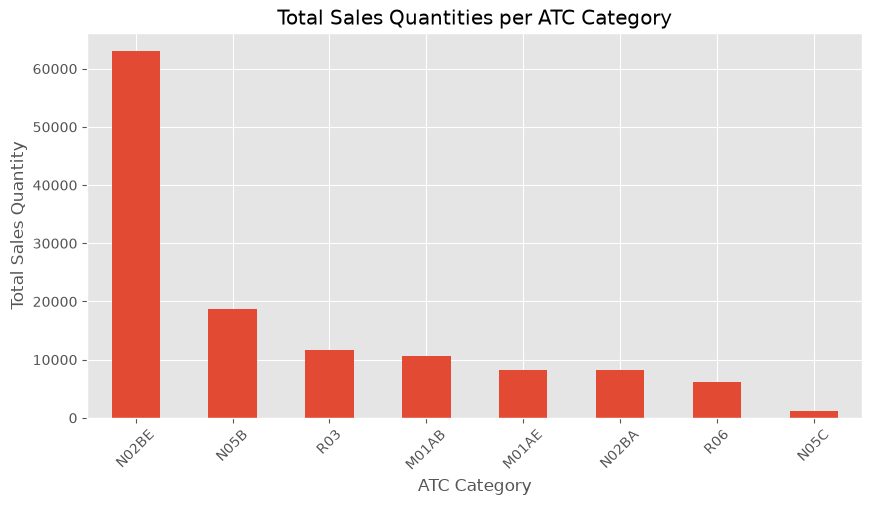

In [ ]:
atc_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
               
               
sales_by_category = df[atc_columns].sum().sort_values(ascending=False)

print("Total Sales Quantities per ATC Category:")
print(sales_by_category)

sales_by_category.plot(
    kind="bar", figsize=(10, 5), title="Total Sales Quantities per ATC Category")

plt.ylabel("Total Sales Quantity")
plt.xlabel("ATC Category")
plt.xticks(rotation=45)
plt.show()


# 2. Which individual drug brands have the highest total sales?

In [21]:
drug_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

top_drugs = df[drug_columns].sum().sort_values(ascending=False)

print("Total Sales by Drug Code:")
print(top_drugs)    


Total Sales by Drug Code:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


# 3. Which three drugs have the highest sales in January 2015, July 2016, September 2017.

In [24]:
drug_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

target_months = [
    {"year": 2015, "month": 1, "label": "January 2015"},
    {"year": 2016, "month": 7, "label": "JULY 2016"},
    {"year": 2017, "month": 9, "label": "September 2017"},
]

for target in target_months:

    filtered_df = df[(df["year"] == target["year"]) & (df["month"] == target["month"])] 

    top_three = filtered_df[drug_columns].sum().nlargest(3)

    print(f"Top 3 Drugs in {target['label']}:")
    print(top_three)
    print("\n")

Top 3 Drugs in January 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64


Top 3 Drugs in JULY 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64


Top 3 Drugs in September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64




# 4. Which drug has sold the most often in 2017?

In [25]:
df_2017 = df[df["Year"] == 2017]

drug_columns = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

top_drug_2017 = df_2017[drug_columns].sum().sort_values(ascending=False)

print("Total Drug Sales in 2017:")
print(top_drug_2017)    


Total Drug Sales in 2017:
N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64


# 5. Which drug category has the highest average daily sales?

In [26]:
drug_column = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

avg_daily_sales = df[drug_columns].mean().sort_values(ascending=False)

print("Average Daily Sales by Drug Code:")
print(avg_daily_sales)  


Average Daily Sales by Drug Code:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


# 6. Are respiratory drugs (R03) sold more during specific months?

Average Daily Sales of R03 by Month:
Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


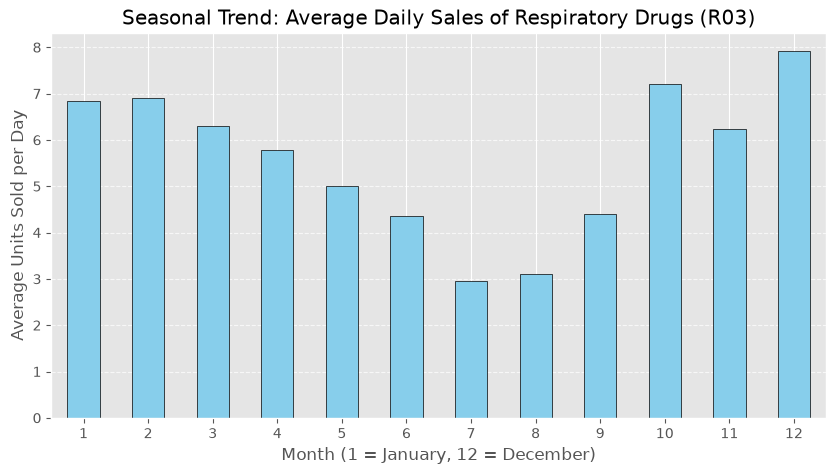

In [27]:
monthly_r03 = df.groupby("Month")["R03"].mean()

print("Average Daily Sales of R03 by Month:")
print(monthly_r03)


#Plotting the average daily sales of R03 by month
plt.figure(figsize=(10, 5))
monthly_r03.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Seasonal Trend: Average Daily Sales of Respiratory Drugs (R03)")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Average Units Sold per Day")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()  
